In [1]:
import geoanalytics
from geoanalytics.tools import *
import matplotlib.pyplot as plt

In [2]:
from demofunctions import *

In [3]:
demo_extent = (-117.292099,32.576844,-116.573868,32.958555)
demo_figsize = (10,10)
demo_style = dict(basemap="streets", figsize=demo_figsize, sr=4326, extent=demo_extent)
demo_rt_style = dict(figsize=demo_figsize, sr=4326, extent=demo_extent)

In [4]:
def bbox_polygon(xmin, ymin, xmax, ymax, sr=None):
    bbox = ST.envelope(ST.multipoint(F.array(ST.point(xmin, ymin), ST.point(xmax, ymax))))
    if sr is not None:
        bbox = ST.srid(bbox, sr)
    return bbox

def generate_h3_bins(resolution, extent):
    return spark.range(1).select(F.explode(ST.h3_bins(bbox_polygon(*extent, sr=4326), resolution)))

def generate_hex_bins(size, extent):
    return spark.range(1).select(F.explode(ST.hex_bins(bbox_polygon(*extent, sr=4326), size)).alias("bin"))\
      .withColumn("bin_geometry", ST.bin_geometry("bin"))


## Demo Theme: Data Enrichment

* through Esri provided demographic data from ACS and U.S. Census datasets
  * https://developers.arcgis.com/geoanalytics/core-concepts/geoenrichment
* local vector data
* local raster data

<Axes: >

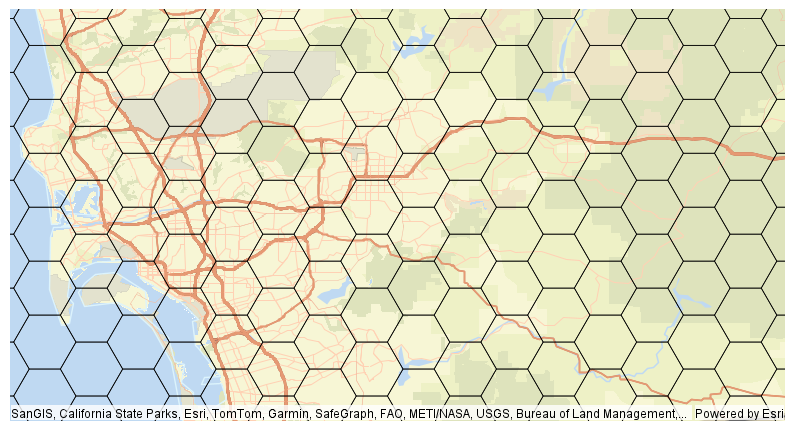

In [5]:
bin_size=.05
bins = generate_hex_bins(bin_size, demo_extent).repartition(12).persist()
bins.st.plot(**demo_style, facecolor="none", edgecolor="black", lw=.5)

In [6]:
enrich_data = r"C:\dev\engine\2.1.0\2.13\GeoEnrich_Essentials_for_ArcGIS_GeoAnalytics_Engine_2.1.0.biz"
enrich_vars = GeoEnrichVariables().setDataPath(enrich_data).run()
print(enrich_vars.count())

431


In [7]:
enrich_vars.where("name like 'HHPOP%'").show(truncate=False)

+-------+-------------------------+------------------------------------------------+
|name   |alias                    |category                                        |
+-------+-------------------------+------------------------------------------------+
|HHPOP00|2000 Household Population|2000 Census Data in 2020 Geography (U.S. Census)|
|HHPOP20|2020 Household Population|2020 Population (U.S. Census)                   |
|HHPOP10|2010 Household Population|2010 Population (U.S. Census)                   |
+-------+-------------------------+------------------------------------------------+



In [8]:
geoenriched_bins = (
    GeoEnrich()
      .setDataPath(enrich_data)
      .setVariables("HHPOP*")
      .run(bins)
      .fillna(0)
)
geoenriched_bins.show(5)

+-------------------+--------------------+-------+-------+-------+
|                bin|        bin_geometry|HHPOP00|HHPOP10|HHPOP20|
+-------------------+--------------------+-------+-------+-------+
|bin#-11592116731253|{"rings":[[[-116....|    295|    274|    552|
|bin#-11600706665844|{"rings":[[[-116....|   9036|  35745|  47291|
|bin#-11626476469617|{"rings":[[[-117....|  22347|  22069|  22549|
|bin#-11566346927474|{"rings":[[[-116....|      0|      0|      0|
|bin#-11596411698542|{"rings":[[[-116....|   2248|   2245|   2342|
+-------------------+--------------------+-------+-------+-------+
only showing top 5 rows


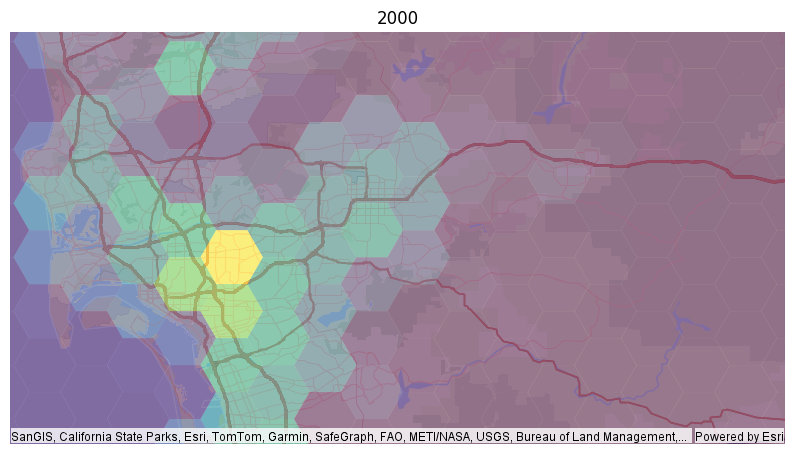

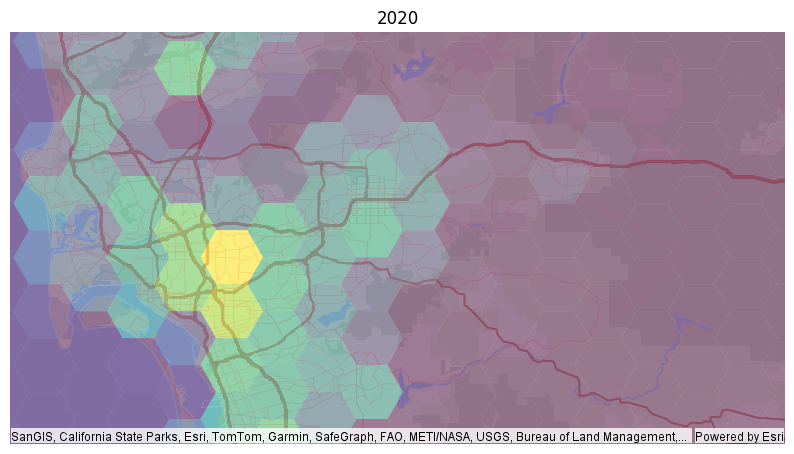

In [9]:
geoenriched_bins.st.plot(**demo_style, cmap_values="HHPOP00", alpha=.5).set_title("2000");
geoenriched_bins.st.plot(**demo_style, cmap_values="HHPOP20", alpha=.5).set_title("2020");

In [10]:
ca_structures = spark.read.format("filegdb")\
  .load(r"C:\dev\demo\2026\ds2026prep\data\ca_structures\CA_Structures.gdb\CA_Structures")\
  .where(ST.bbox_intersects("shape", *demo_extent))\
  .select("shape")\
  .hint("rebalance")
ca_structures.persist().count()

479042

<Axes: >

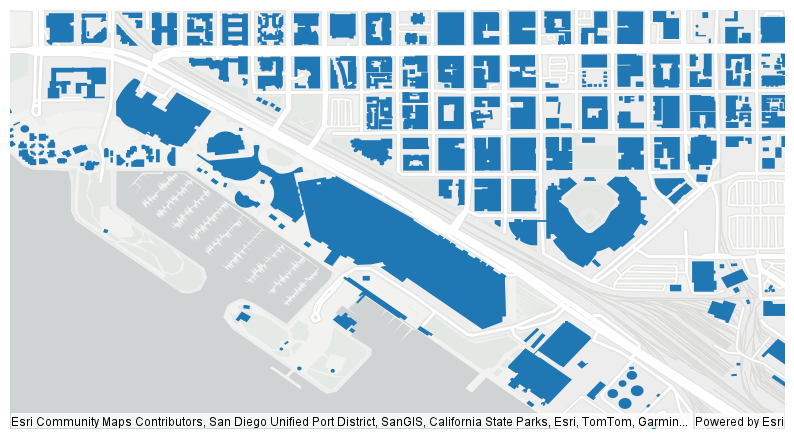

In [11]:
convention_center_extent=(-117.171764,32.701887,-117.152109,32.712526)
ca_structures.st.plot(basemap="light", figsize=demo_figsize, extent=convention_center_extent)

In [12]:
structure_enriched_bins = ca_structures.withColumn("bin", ST.hex_bin("shape", bin_size))\
  .groupBy("bin").agg(
      F.count("*").alias("num_structures"),
      F.sum(ST.geodesic_area("shape")).alias("sum_structure_area")
  )\
  .persist()
structure_enriched_bins.show(5)

+-------------------+--------------+------------------+
|                bin|num_structures|sum_structure_area|
+-------------------+--------------+------------------+
|bin#-11562051960176|             2|376.97453237263693|
|bin#-11574936862066|            96| 18698.89044989721|
|bin#-11562051960175|            17| 3130.730736020416|
|bin#-11583526796660|           276| 39684.64789241226|
|bin#-11596411698546|           203| 50658.98614025951|
+-------------------+--------------+------------------+
only showing top 5 rows


In [13]:
enriched_bins = geoenriched_bins.join(structure_enriched_bins, on="bin", how="leftouter").fillna(0)
enriched_bins.show(5)

+-------------------+--------------------+-------+-------+-------+--------------+------------------+
|                bin|        bin_geometry|HHPOP00|HHPOP10|HHPOP20|num_structures|sum_structure_area|
+-------------------+--------------------+-------+-------+-------+--------------+------------------+
|bin#-11592116731253|{"rings":[[[-116....|    295|    274|    552|             0|               0.0|
|bin#-11600706665844|{"rings":[[[-116....|   9036|  35745|  47291|          8765|2128860.8777589784|
|bin#-11626476469617|{"rings":[[[-117....|  22347|  22069|  22549|          6868|1978640.6324964508|
|bin#-11566346927474|{"rings":[[[-116....|      0|      0|      0|             3|220.66868698307786|
|bin#-11596411698542|{"rings":[[[-116....|   2248|   2245|   2342|          1096| 263793.9905258253|
+-------------------+--------------------+-------+-------+-------+--------------+------------------+
only showing top 5 rows


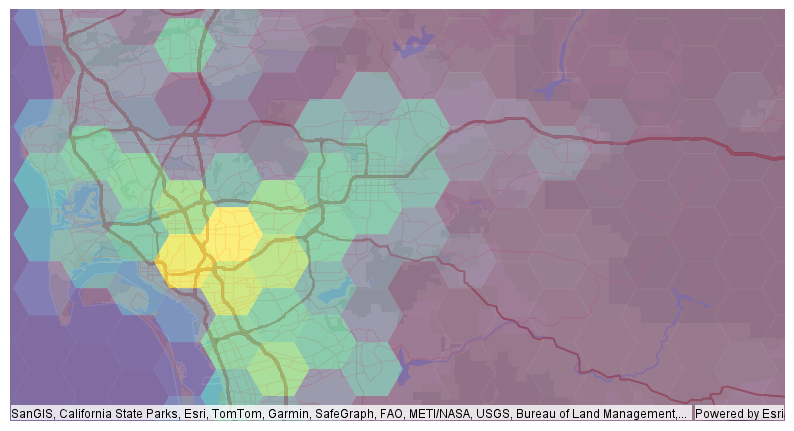

In [14]:
enriched_bins.st.plot(**demo_style, cmap_values="num_structures", alpha=.5);

In [15]:
landcover = spark.read.format("raster").load(r"C:\dev\demo\2026\ds2026prep\data\landcover\year=2024")\
  .where(ST.bbox_intersects(RT.extent("raster", 4326), *demo_extent))\
  .withColumn("raster", RT.materialize("raster"))\
  .persist()
landcover.show(truncate=False)

+----------------------------------------------------------------------------------------------+-----------------------------+
|path                                                                                          |raster                       |
+----------------------------------------------------------------------------------------------+-----------------------------+
|file:/C:/dev/demo/2026/ds2026prep/data/landcover/year=2024/Annual_NLCD_LndCov_2024_CU_C1V1.tif|SqlRaster(1x1024x1024, UInt8)|
|file:/C:/dev/demo/2026/ds2026prep/data/landcover/year=2024/Annual_NLCD_LndCov_2024_CU_C1V1.tif|SqlRaster(1x1024x1024, UInt8)|
|file:/C:/dev/demo/2026/ds2026prep/data/landcover/year=2024/Annual_NLCD_LndCov_2024_CU_C1V1.tif|SqlRaster(1x1024x1024, UInt8)|
|file:/C:/dev/demo/2026/ds2026prep/data/landcover/year=2024/Annual_NLCD_LndCov_2024_CU_C1V1.tif|SqlRaster(1x1024x1024, UInt8)|
|file:/C:/dev/demo/2026/ds2026prep/data/landcover/year=2024/Annual_NLCD_LndCov_2024_CU_C1V1.tif|SqlRaster(1x102

<Axes: >

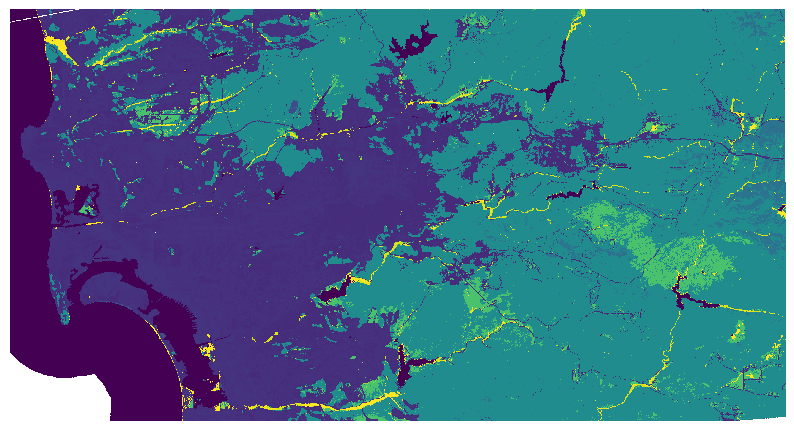

In [16]:
landcover.rt.plot(**demo_rt_style)

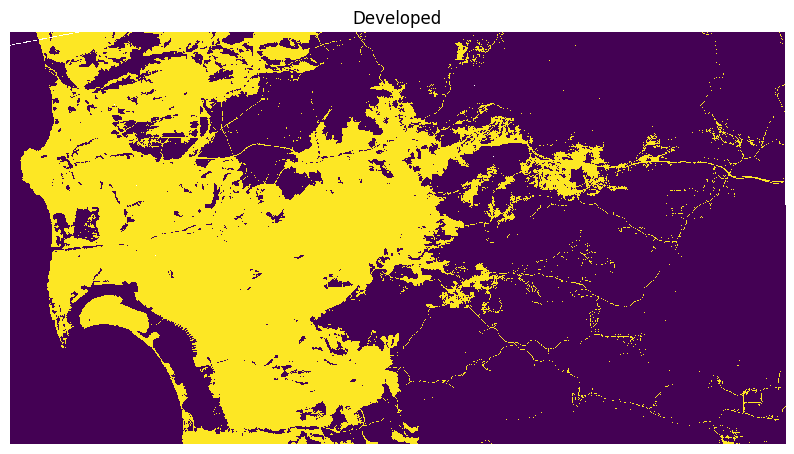

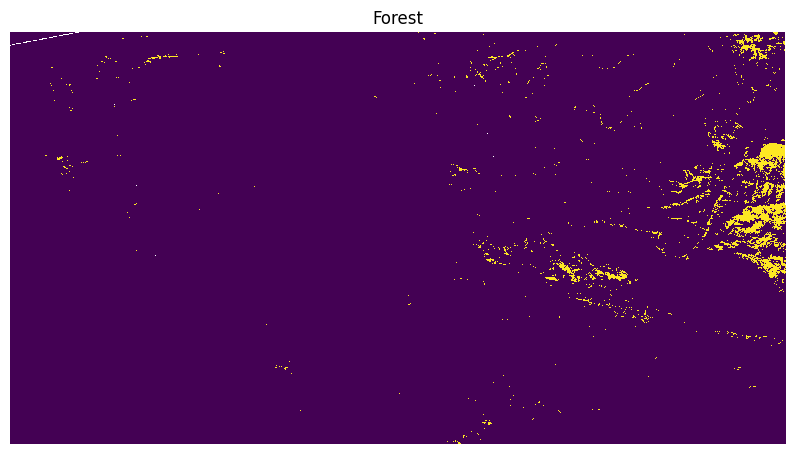

In [17]:
def binarize_range(raster, band, min_val, max_val):
    return RT.apply(raster, band, lambda px: F.when(px.values[0].between(min_val, max_val), F.lit(1)).otherwise(F.lit(0)))

developed_range = [20, 29]
forest_range = [40, 45]

landcover_processed = landcover.withColumn("raster", binarize_range("raster", 2, *developed_range))\
                               .withColumn("raster", binarize_range("raster", 3, *forest_range))

landcover_processed.rt.plot(**demo_rt_style, band_ids=2).set_title("Developed")
landcover_processed.rt.plot(**demo_rt_style, band_ids=3).set_title("Forest");

In [18]:
landcover_processed.withColumn("developed_stats", RT.band_statistics("raster", 2)).select("developed_stats.*").show()

+---+---+--------------------+-------------------+
|min|max|                mean|              stdev|
+---+---+--------------------+-------------------+
|0.0|1.0|  0.1774768829345718|0.38207195418507217|
|0.0|1.0| 0.20501422882078618| 0.4037122121450235|
|0.0|1.0|   0.561798095703126| 0.4961665346878854|
|0.0|1.0| 0.07120227813720441|0.25716254936171584|
|0.0|1.0|0.013907432556152613|0.11710691249693671|
|0.0|1.0| 0.27006816864013483| 0.4439949784927595|
|0.0|1.0|0.017036437988281396|0.12940716262783605|
+---+---+--------------------+-------------------+



In [19]:
zonal_stats_bins = (
    ZonalStatistics()
      .setRasterColumn("raster")
      .setBandIds(2, 3)
      .setZones(enriched_bins)
      .setZoneIdColumns("bin")
      .run(landcover_processed)
      .localCheckpoint()
)
zonal_stats_bins.printSchema()
zonal_stats_bins.selectExpr("bin", "bandid", "sum", "count", "round(mean, 2) as mean").show(5)

root
 |-- bin: bin2d (nullable = false)
 |-- BandID: integer (nullable = true)
 |-- Count: long (nullable = true)
 |-- Min: double (nullable = true)
 |-- Max: double (nullable = true)
 |-- Range: double (nullable = true)
 |-- Mean: double (nullable = true)
 |-- Stdev: double (nullable = true)
 |-- Sum: double (nullable = true)
 |-- Variety: long (nullable = true)
 |-- Majority: double (nullable = true)
 |-- MajorityCount: long (nullable = true)
 |-- MajorityPercent: double (nullable = true)
 |-- Minority: double (nullable = true)
 |-- MinorityCount: long (nullable = true)
 |-- MinorityPercent: double (nullable = true)

+-------------------+------+------+-----+----+
|                bin|bandid|   sum|count|mean|
+-------------------+------+------+-----+----+
|bin#-11605001633133|     2|3221.0|17479|0.18|
|bin#-11605001633133|     3|   0.0|17479| 0.0|
|bin#-11605001633134|     2| 326.0|17562|0.02|
|bin#-11605001633134|     3|   0.0|17562| 0.0|
|bin#-11617886535021|     2|7222.0| 9415|0.7

In [20]:
zonal_stats_bins_wide = zonal_stats_bins.groupBy("bin").pivot("bandid").agg(F.round(F.any_value("mean"), 2).alias("mean"))\
  .withColumnRenamed("2", "ratio_developed")\
  .withColumnRenamed("3", "ratio_forest")
zonal_stats_bins_wide.show(5)

+-------------------+---------------+------------+
|                bin|ratio_developed|ratio_forest|
+-------------------+---------------+------------+
|bin#-11562051960176|           0.01|        0.38|
|bin#-11574936862066|           0.01|        0.01|
|bin#-11562051960175|           0.03|        0.32|
|bin#-11596411698546|           0.04|         0.0|
|bin#-11583526796660|           0.03|         0.0|
+-------------------+---------------+------------+
only showing top 5 rows


In [21]:
enriched_bins2 = enriched_bins.join(zonal_stats_bins_wide, on="bin", how="leftouter").localCheckpoint()
enriched_bins2.drop("bin_geometry").show(5)

+-------------------+-------+-------+-------+--------------+------------------+---------------+------------+
|                bin|HHPOP00|HHPOP10|HHPOP20|num_structures|sum_structure_area|ratio_developed|ratio_forest|
+-------------------+-------+-------+-------+--------------+------------------+---------------+------------+
|bin#-11600706665844|   9036|  35745|  47291|          8765|2128860.8777589784|           0.69|         0.0|
|bin#-11622181502322|  25740|  38278|  47624|          6328|3047939.6911309655|           0.64|         0.0|
|bin#-11566346927474|      0|      0|      0|             3|220.66868698307786|            0.0|        0.05|
|bin#-11583526796653|    837|   1078|   1158|             0|               0.0|           0.04|         0.0|
|bin#-11562051960178|     11|     15|     14|             0|               0.0|            0.0|        0.05|
+-------------------+-------+-------+-------+--------------+------------------+---------------+------------+
only showing top 5 

In [22]:
from ipywidgets import interact, widgets

def draw_bins(cmap_values):
    enriched_bins2.st.plot(**demo_style, cmap_values=cmap_values, alpha=.8)
    plt.show()

interact(draw_bins, cmap_values=["HHPOP00","HHPOP10","HHPOP20","num_structures","sum_structure_area","ratio_developed","ratio_forest"]);

interactive(children=(Dropdown(description='cmap_values', options=('HHPOP00', 'HHPOP10', 'HHPOP20', 'num_struc…